In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.3.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_56_nemomod_entc,group_57_nemomod_entc,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution
0,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,0.318541,0.019632,0.206847,...,0.110602,0.228879,0.023251,0.519864,228.689851,6450.512091,1.089195e+09,2.896456e+10,0.0,31.872189
1,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,0.659673,0.269362,0.823100,...,0.890292,0.243776,0.881897,0.307468,251.347424,6683.626925,1.063473e+09,2.665439e+10,0.0,13.453895
2,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,0.492968,0.757714,0.625087,...,0.228748,0.148648,0.914823,0.078667,184.690777,5766.140732,1.047608e+09,2.947961e+10,0.0,20.233116
3,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,0.185125,0.179946,0.490353,...,0.114697,0.215141,0.400283,0.013558,279.158564,7107.472492,9.955428e+08,2.995237e+10,0.0,20.155143
4,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,0.692139,0.655440,0.369429,...,0.042683,0.369231,0.453588,0.800351,336.834484,7737.210438,1.074846e+09,3.234731e+10,0.0,26.887590


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if not(col.startswith("group_"))]
target_cols

['emission_avg_last_five_years',
 'total_emissions',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_nemomod_entc_frac_min_share_production_fp_hydrogen',
 'group_6_nemomod_en',
 'group_7_',
 'group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_9_efficfactor_enfu_industrial_energy_fuel',
 'group_10_scalar_inen_energy_demand',
 'group_11_frac_inen_energy',
 'group_12_frac_ippu_cement_clinker',
 'group_13_ef_ippu_tonne_c',
 'group_14_ef_ippu_tonne_n2o_per_tonne_production',
 'group_15_ef_ippu_tonne_c',
 'group_16_pij_lndu',
 'group_17_frac_lndu_improved_pastures',
 'group_18_lndu_reallocation_factor',
 'group_19_gasrf_lsmm_biogas_anaerobic',
 'group_20_frac_lvst_mm',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm_chickens',
 'group_23_ef_lvst_entferm',
 'group_24_frac_gnrl_eating_red_meat',
 'group_25_frac_ippu_production_with_co2_capture',
 'group_26_scalar_scoe_heat_energy_de

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution
count,1.980000e+02,1.980000e+02,1.980000e+02,1.980000e+02,198.000000,198.000000
mean,7.002529e+04,5.704791e+05,9.238803e+08,3.021716e+10,6730.774474,26.044062
std,7.780241e+05,4.719693e+06,1.072294e+08,1.946968e+09,54054.249882,6.801740
min,1.569154e+01,3.374673e+03,7.283327e+08,2.471662e+10,0.000000,7.568973
25%,1.295568e+02,5.037959e+03,8.288559e+08,2.883276e+10,1999.274880,20.602403
50%,1.598834e+02,5.466282e+03,9.126740e+08,3.036828e+10,2429.878895,26.736687
75%,2.011651e+02,6.024036e+03,1.003634e+09,3.157286e+10,2917.128104,31.675347
max,1.041955e+07,5.210267e+07,1.200847e+09,3.563266e+10,756882.695309,39.589047


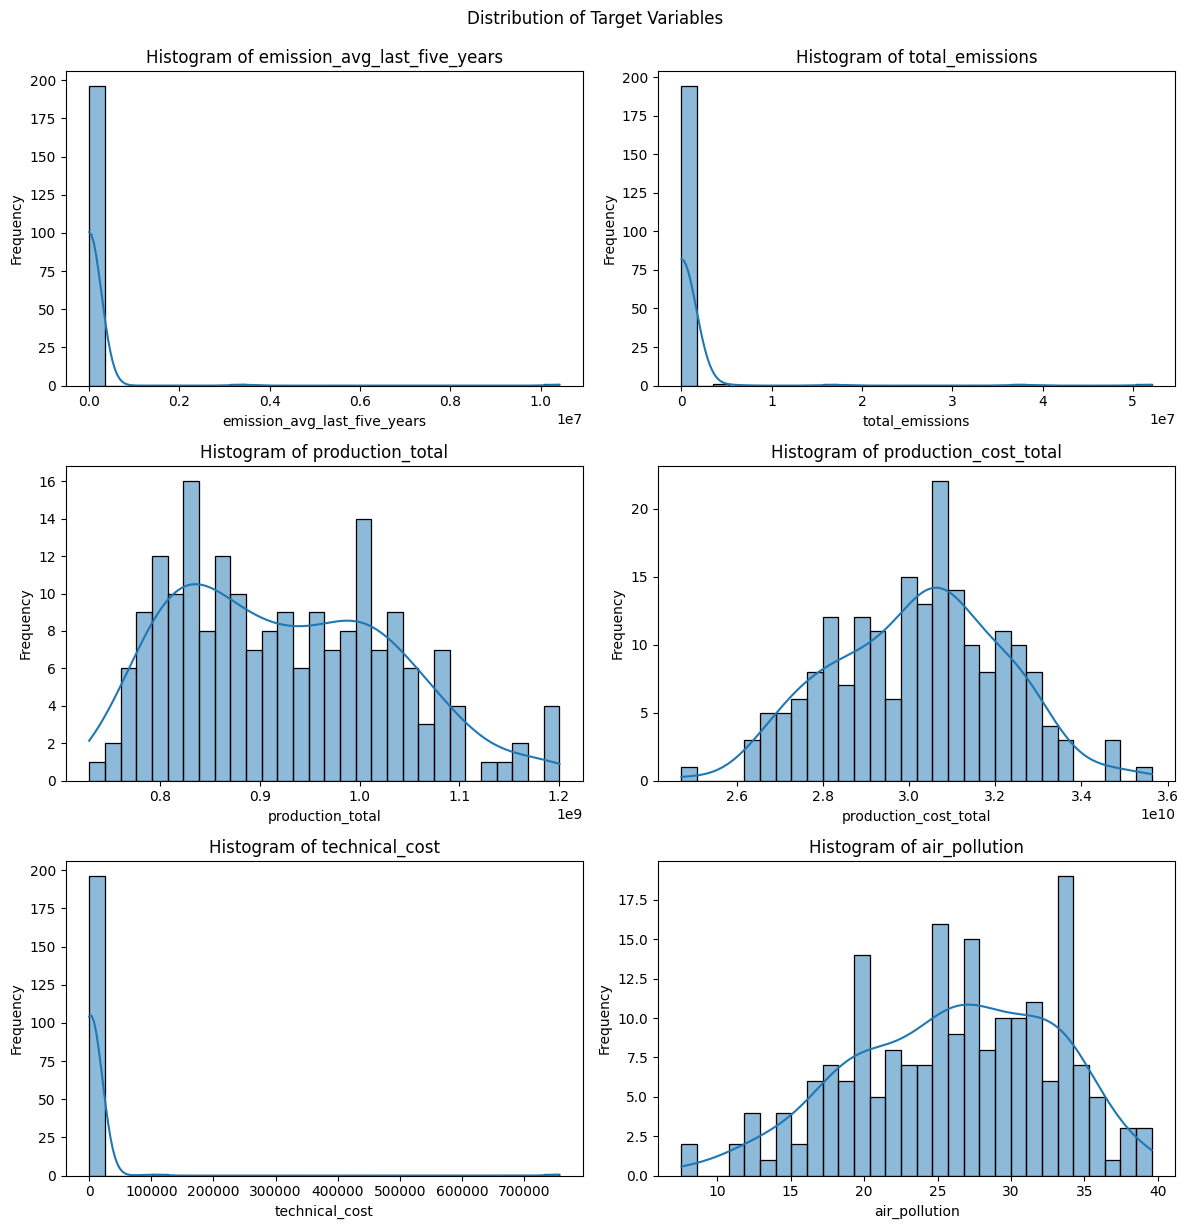

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [11]:
edau.get_target_var_corr(training_df, "total_emissions", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)


Correlation with target variable 'total_emissions' (threshold: 0.1):
--------------------------------------------------
group_29_demscalar_soil_liming_per_area : 0.1459
group_57_nemomod_entc          : 0.1349
group_59_elasticity_trde_pkm_to_gdppc : 0.1310
group_43_frac_waso             : 0.1195
group_56_nemomod_entc          : 0.1178
group_40_frac_trns_pkm_dem_private_and_public : 0.1147
group_35_frac_trns_fuelmix_road_light : 0.1105
group_10_scalar_inen_energy_demand : 0.1046
group_27_scalar_scoe_appliance_energy_demand : 0.1026


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_29_demscalar_soil_liming_per_area : 0.1415
group_56_nemomod_entc          : 0.1246
group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel : 0.1224
group_28_frac_scoe_heat_energy : 0.1217
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.1150
group_30_demscalar_soil_fertilizer_n_per_area : 0.1087
group_1

In [12]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [13]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 3.54, 'total_emissions': 4.04, 'production_cost_total': 0.51, 'technical_cost': 4.04}


## Data Cleaning

In [14]:
dcu = DataCleaningUtils()

In [15]:
training_df.shape

(198, 65)

In [16]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [17]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [18]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (198, 65)
Shape after removing outliers: (183, 65)


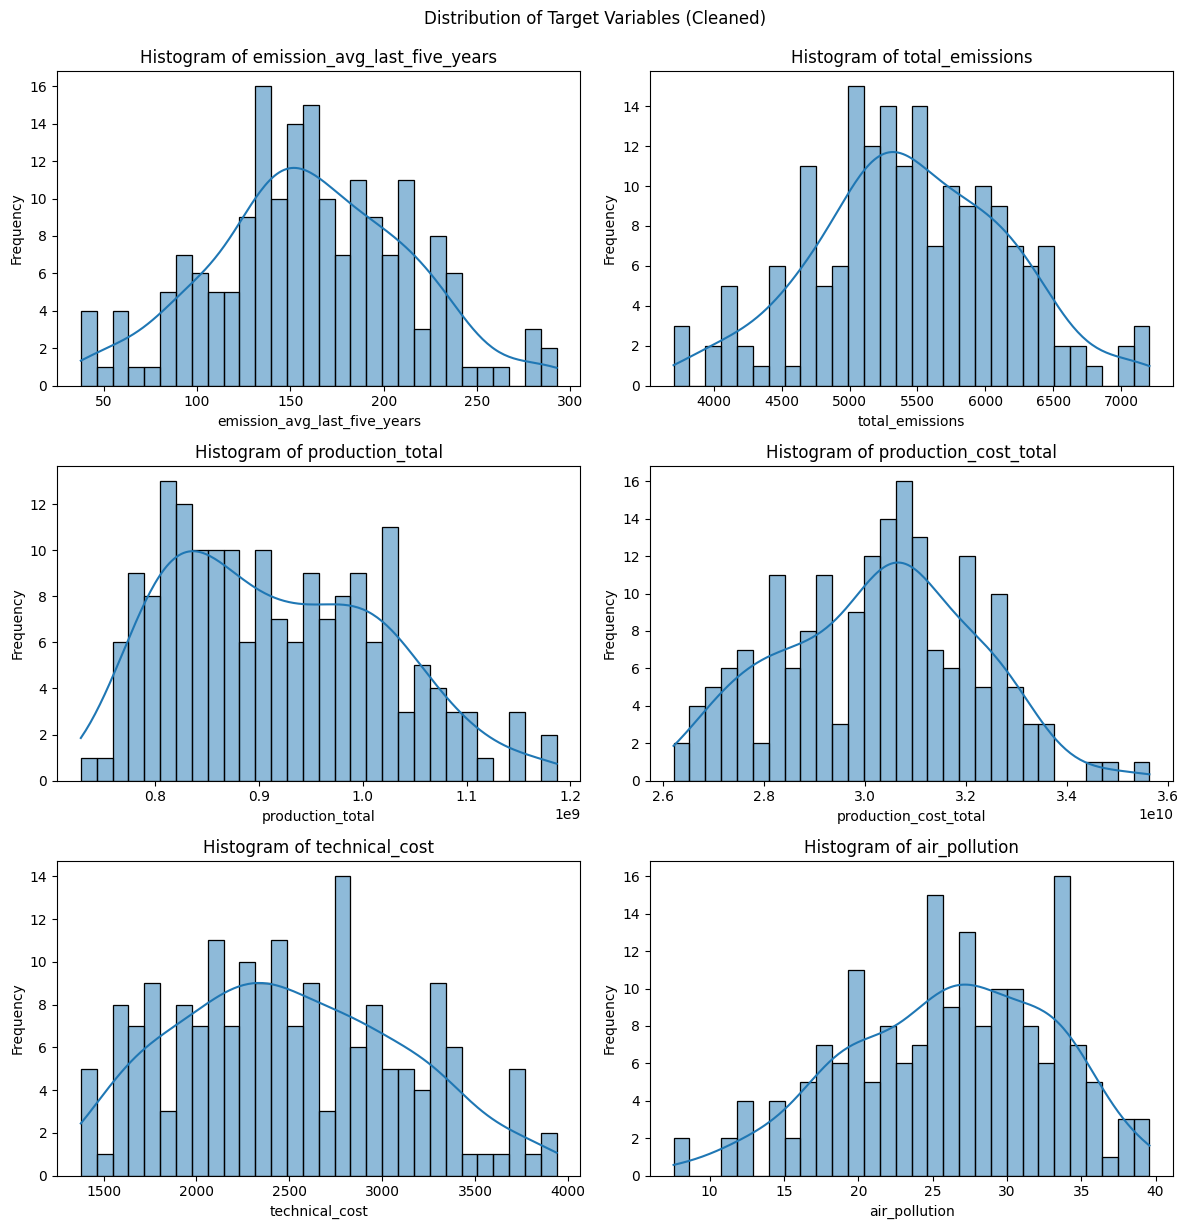

In [19]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [20]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [22]:
edau.get_target_var_corr(training_df, "total_emissions", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)


Correlation with target variable 'total_emissions' (threshold: 0.1):
--------------------------------------------------
group_29_demscalar_soil_liming_per_area : 0.1459
group_57_nemomod_entc          : 0.1349
group_59_elasticity_trde_pkm_to_gdppc : 0.1310
group_43_frac_waso             : 0.1195
group_56_nemomod_entc          : 0.1178
group_40_frac_trns_pkm_dem_private_and_public : 0.1147
group_35_frac_trns_fuelmix_road_light : 0.1105
group_10_scalar_inen_energy_demand : 0.1046
group_27_scalar_scoe_appliance_energy_demand : 0.1026


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_29_demscalar_soil_liming_per_area : 0.1415
group_56_nemomod_entc          : 0.1246
group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel : 0.1224
group_28_frac_scoe_heat_energy : 0.1217
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.1150
group_30_demscalar_soil_fertilizer_n_per_area : 0.1087
group_1

In [23]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,total_emissions,production_total,production_cost_total,technical_cost,air_pollution
count,183.000000,183.000000,1.830000e+02,1.830000e+02,183.000000,183.000000
mean,160.272591,5449.866280,9.173468e+08,3.025358e+10,2500.279936,26.057390
std,52.821517,711.205627,1.027881e+08,1.898543e+09,607.639239,6.827726
min,37.758826,3704.551466,7.283327e+08,2.621028e+10,1377.632562,7.568973
25%,128.988959,5037.198986,8.284427e+08,2.886794e+10,2037.981095,20.918540
50%,158.933468,5426.166552,9.066266e+08,3.046084e+10,2432.702125,26.721660
75%,196.682614,5952.804123,9.979127e+08,3.160541e+10,2931.780676,31.416665
max,292.706041,7208.526133,1.186875e+09,3.563266e+10,3940.127199,39.589047


In [24]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [25]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [26]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [27]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [28]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training


=== XGB ===
emission_avg_last_five_years  
  Train → MAE: 0.0003, RMSE: 0.0004, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 23.5971, RMSE: 29.4237, R²: 0.7588, SMAPE: 17.7%
total_emissions               
  Train → MAE: 0.0004, RMSE: 0.0005, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 246.0991, RMSE: 328.7881, R²: 0.8303, SMAPE: 4.7%
production_total              
  Train → MAE: 66.1758, RMSE: 79.3515, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 20713970.8600, RMSE: 28112103.0517, R²: 0.9192, SMAPE: 2.3%
production_cost_total         
  Train → MAE: 1898.6123, RMSE: 2305.5851, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 813853936.2405, RMSE: 1037989114.1718, R²: 0.6907, SMAPE: 2.7%
technical_cost                
  Train → MAE: 0.0003, RMSE: 0.0004, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 219.0235, RMSE: 261.3233, R²: 0.7528, SMAPE: 8.9%
air_pollution                 
  Train → MAE: 0.0003, RMSE: 0.0004, R²: 1.0000, SMAPE: 0.0%
   Test → MAE: 3.1865, RMSE: 3.9357, R²: 0.7439, SMAPE: 15.2%

=== MeanBaseline 

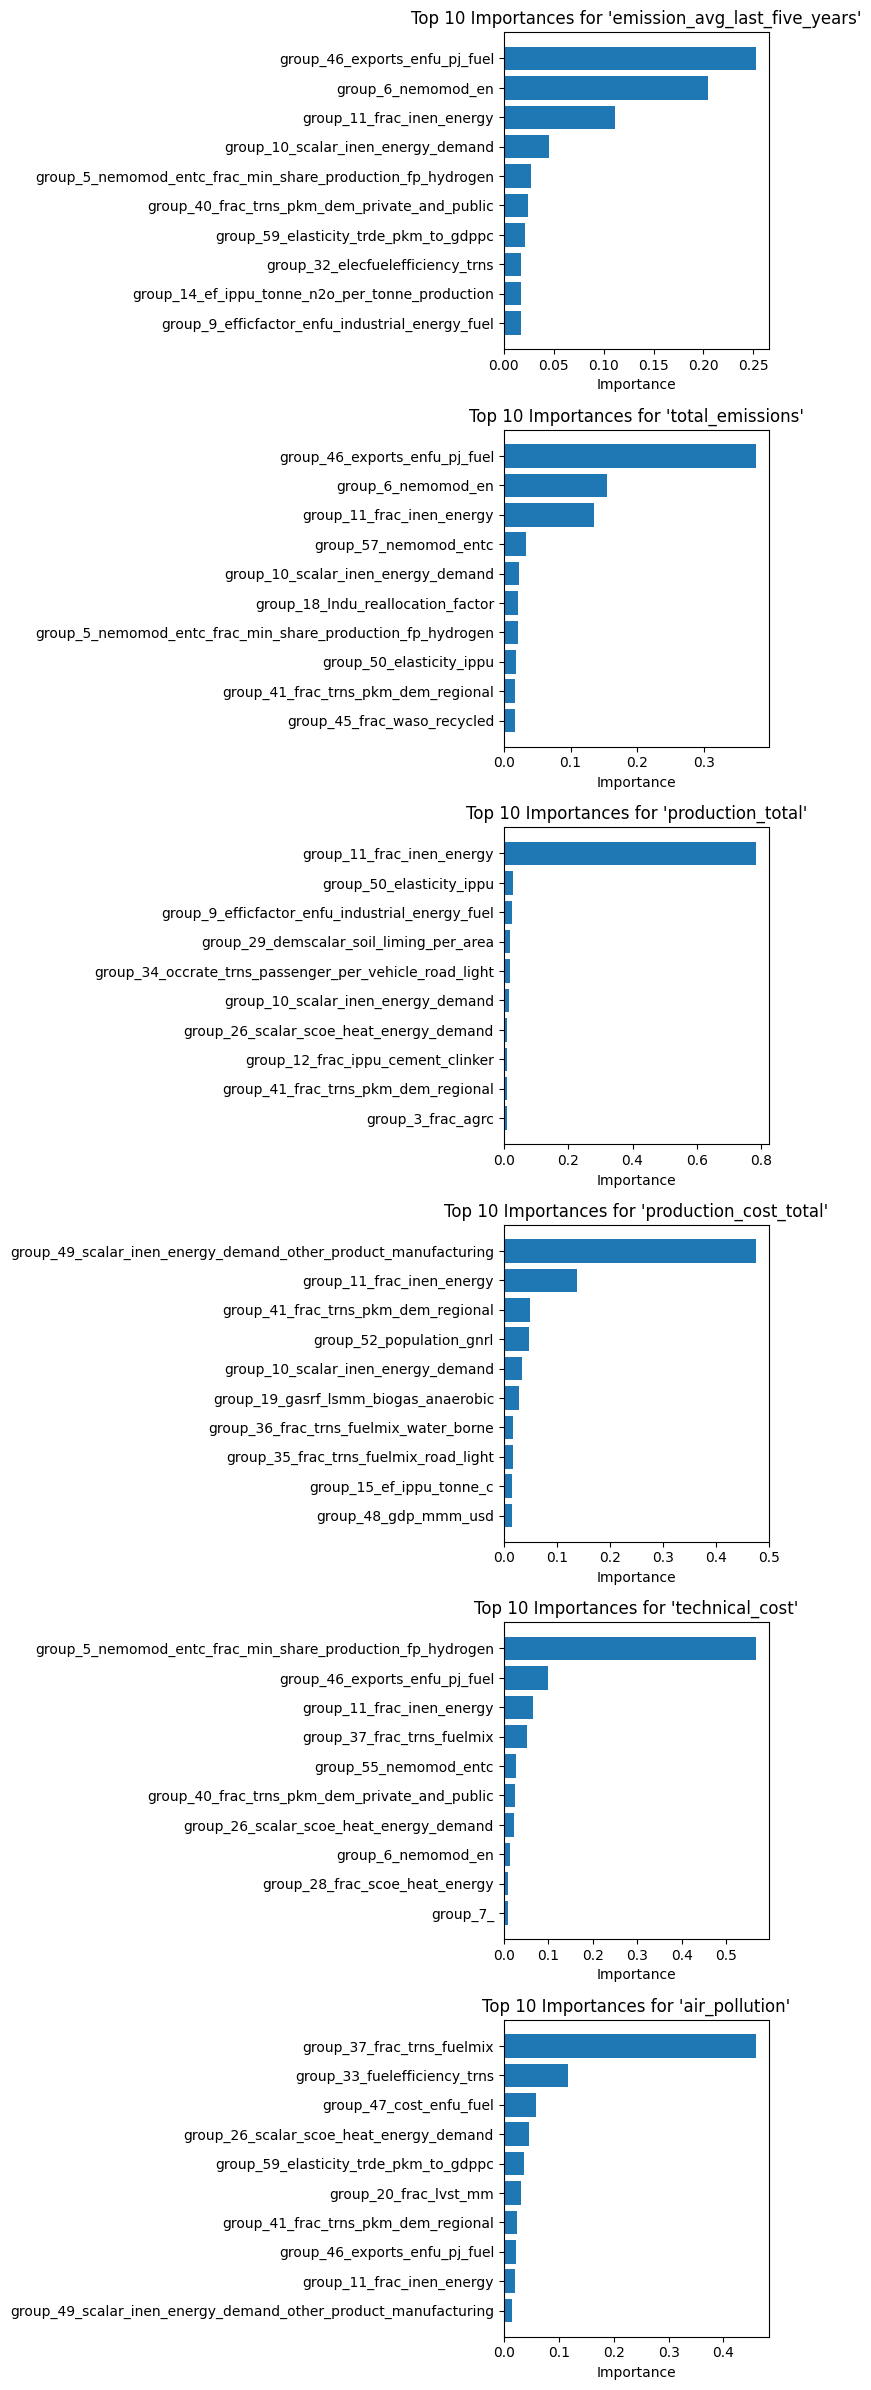

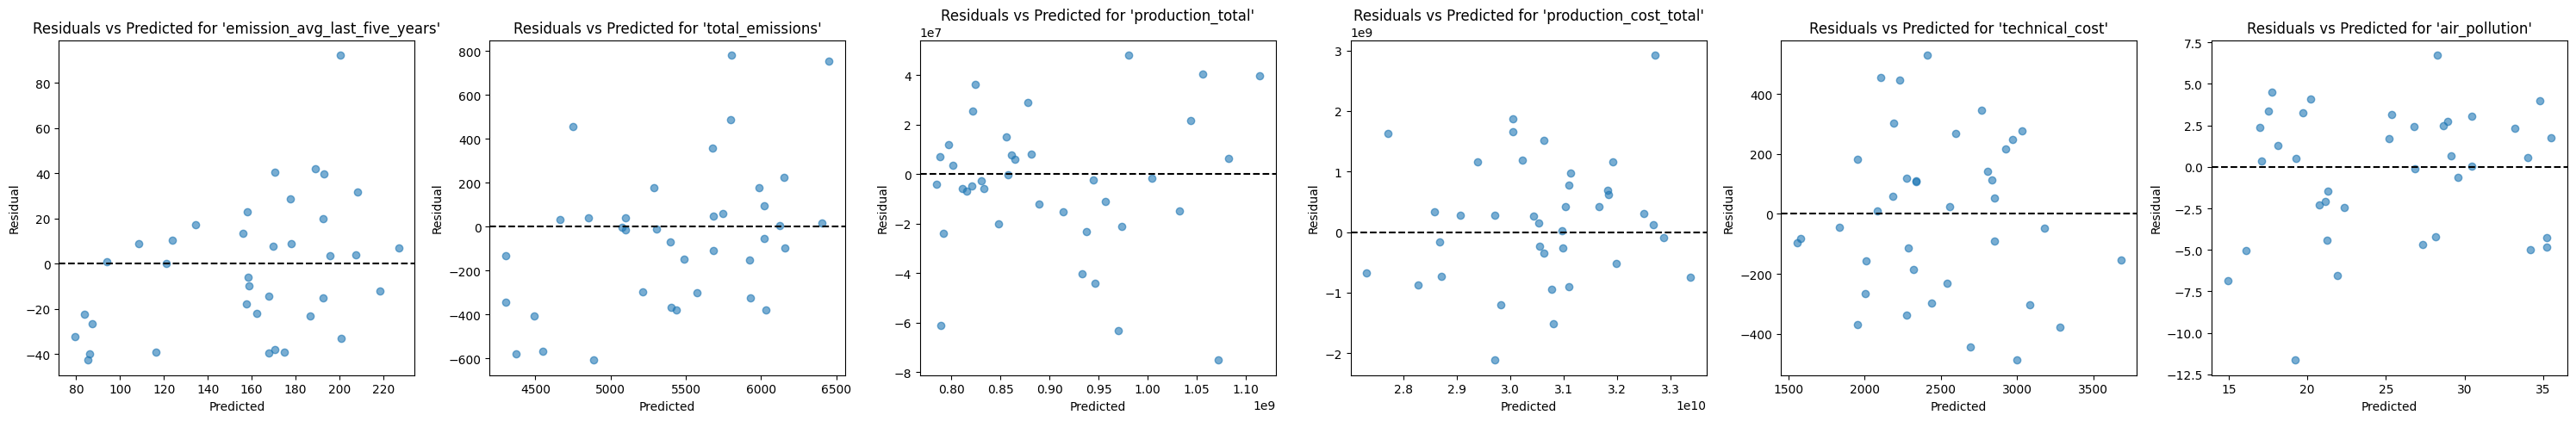

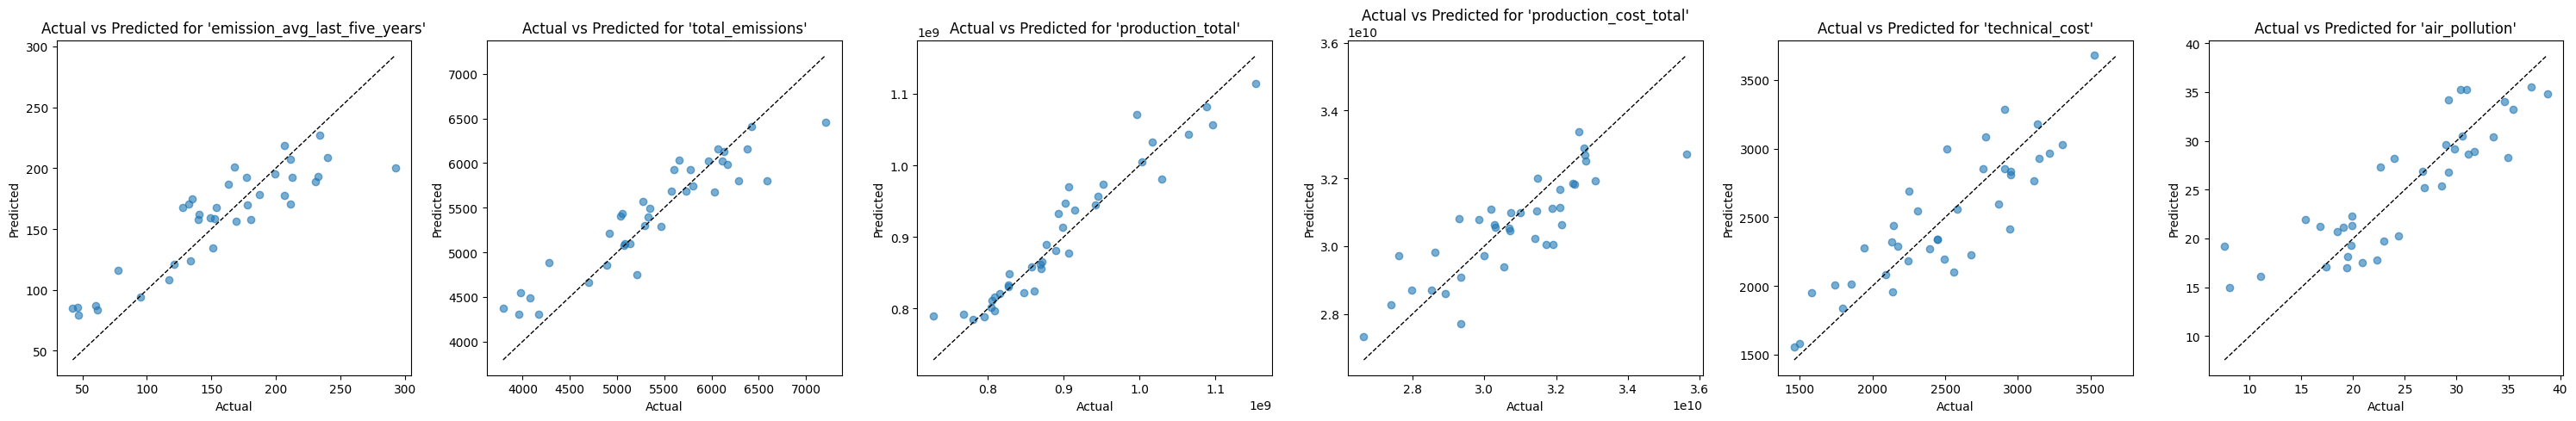

In [30]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=target_cols)
mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [30]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,consumer_savings,human_health
0,0.354682,0.681300,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.199758,0.969220,198.512688,6648.349151,9.944817e+08,1.209662e+10,72.057617,39.031999,10.909213,7.444526
1,0.023662,0.659807,0.066549,0.350365,0.536160,0.040042,0.101776,0.683933,0.343598,0.707471,...,0.725034,0.902345,228.001674,7129.331813,7.733990e+08,1.427672e+10,-13.958464,20.164441,9.862279,8.685293
2,0.414641,0.092022,0.227137,0.020454,0.832906,0.293800,0.601890,0.263913,0.878754,0.211035,...,0.208350,0.175365,182.853198,6396.992675,7.860210e+08,1.501253e+10,35.944249,35.268119,9.606087,8.469585
3,0.307337,0.204967,0.050181,0.805452,0.558369,0.506111,0.974177,0.923617,0.904693,0.923400,...,0.227383,0.113647,132.272042,5771.905648,7.332484e+08,1.419782e+10,-5.660414,34.670174,9.917888,8.909666
4,0.800355,0.458285,0.101171,0.738594,0.254548,0.034029,0.673997,0.851671,0.418375,0.308669,...,0.947292,0.764492,173.059694,6393.870401,9.001498e+08,1.355211e+10,-14.126208,32.423383,9.132959,6.719518


In [31]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(target_cols)
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_frac_enfu_transmission_loss_fuel_electricity,group_6_nemomod_entc_frac_min_share_production_fp_hydrogen_electrolysis,group_7_nemomod_en,group_8_frac_fgtv_reduction_in_fugitive_leaks,group_9_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_10_efficfactor_enfu_industrial_energy_fuel,...,group_49_nemomod_entc,group_50_nemomod_enst_capital_cost_st,group_51_exports_enfu_pj_fuel,group_52_gdp_mmm_usd,group_53_population_gnrl,group_54_elasticity_scoe_enerdem_per,group_55_elasticity_trde_mtkm_to_gdp_freight,group_56_elasticity_trde_pkm_to_gdppc,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use
0,0.354682,0.6813,0.670551,0.371381,0.597378,0.390717,0.554668,0.176302,0.653196,0.648621,...,0.115895,0.456909,0.389376,0.065254,0.452244,0.395609,0.190891,0.681412,0.199758,0.96922


In [ ]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    197.272156     6639.711426       996680576.0   

   production_cost_total  technical_cost  air_pollution  consumer_savings  \
0           1.208855e+10       67.379219       39.29166         11.017798   

   human_health  
0       7.41676  
Original values:
emission_avg_last_five_years    1.985127e+02
emission_total                  6.648349e+03
production_total                9.944817e+08
production_cost_total           1.209662e+10
technical_cost                  7.205762e+01
air_pollution                   3.903200e+01
consumer_savings                1.090921e+01
human_health                    7.444526e+00
Name: 0, dtype: float64


In [33]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.3.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.3.pkl to /Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/notebooks/trained_models/xgb_pipeline_5.3.pkl.


In [34]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [35]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
0                    197.272156     6639.711426       996680576.0   

   production_cost_total  technical_cost  air_pollution  consumer_savings  \
0           1.208855e+10       67.379219       39.29166         11.017798   

   human_health  
0       7.41676  
